In [2]:
import os

print(os.getcwd())

f:\final project\notebooks\data


In [3]:
import pandas as pd

df = pd.read_csv("house_prices.csv")
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [4]:
# عرض عدد الصفوف والأعمدة
print("Shape of dataset:", df.shape)

# عرض أسماء الأعمدة
print("\nColumns:")
print(df.columns)

Shape of dataset: (187531, 21)

Columns:
Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='str')


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [6]:
df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [7]:
# حذف الأعمدة الفارغة بالكامل
df.drop(columns=["Dimensions", "Plot Area"], inplace=True)

# حذف الصفوف التي لا تحتوي على السعر
df.dropna(subset=["Price (in rupees)"], inplace=True)

# التأكد من شكل البيانات بعد الحذف
print(df.shape)

# التأكد من عدم وجود قيم ناقصة في السعر
print(df["Price (in rupees)"].isnull().sum())

(169866, 19)
0


In [8]:
# حذف الأعمدة غير المهمة
df.drop(columns=["Title", "Description", "Society"], inplace=True)

# التأكد من الأعمدة المتبقية
print(df.columns)

Index(['Index', 'Amount(in rupees)', 'Price (in rupees)', 'location',
       'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing',
       'overlooking', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership',
       'Super Area'],
      dtype='str')


In [9]:
# معرفة عدد القيم المفقودة بعد التنظيف
df.isnull().sum()

Index                    0
Amount(in rupees)        0
Price (in rupees)        0
location                 0
Carpet Area          76235
Status                 595
Floor                 6843
Transaction              6
Furnishing            2060
facing               62052
overlooking          70646
Bathroom               754
Balcony              45062
Car Parking          90950
Ownership            58237
Super Area           93631
dtype: int64

In [10]:
# ملء القيم المفقودة في الأعمدة النصية بكلمة Unknown
categorical_columns = [
    "Carpet Area",
    "Status",
    "Floor",
    "Transaction",
    "Furnishing",
    "facing",
    "overlooking",
    "Bathroom",
    "Balcony",
    "Car Parking",
    "Ownership",
    "Super Area"
]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

# التأكد من عدم وجود قيم مفقودة
print(df.isnull().sum())

Index                0
Amount(in rupees)    0
Price (in rupees)    0
location             0
Carpet Area          0
Status               0
Floor                0
Transaction          0
Furnishing           0
facing               0
overlooking          0
Bathroom             0
Balcony              0
Car Parking          0
Ownership            0
Super Area           0
dtype: int64


In [11]:
from sklearn.preprocessing import LabelEncoder

# إنشاء LabelEncoder
le = LabelEncoder()

# تحويل جميع الأعمدة النصية إلى أرقام
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# التأكد من شكل البيانات
df.head()

C:\Users\Al Badr\AppData\Local\Temp\ipykernel_12640\888905217.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,Index,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Car Parking,Ownership,Super Area
0,0,773,6000.0,67,1932,0,39,3,2,7,18,0,2,205,4,2897
1,1,1538,13799.0,67,1892,0,544,3,1,0,0,2,11,2,1,2897
2,2,44,17500.0,67,2307,0,57,3,2,0,0,2,11,0,1,2897
4,4,65,18824.0,67,2117,0,377,3,2,8,1,2,11,0,0,2897
5,5,803,6618.0,67,2590,0,352,3,2,0,1,0,0,205,0,2497


In [12]:
from sklearn.model_selection import train_test_split

# تحديد المدخلات (Features)
X = df.drop("Price (in rupees)", axis=1)

# تحديد المخرجات (Target)
y = df["Price (in rupees)"]

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (135892, 15)
Testing data: (33974, 15)


In [13]:
from sklearn.ensemble import RandomForestRegressor

# إنشاء الموديل
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# تدريب الموديل
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [14]:
from sklearn.metrics import mean_absolute_error, r2_score

# التنبؤ على بيانات الاختبار
y_pred = model.predict(X_test)

# حساب النتائج
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 736.2438073232472
R2 Score: 0.000678609293060517


In [15]:
df["Amount(in rupees)"].head(10)

0      773
1     1538
2       44
4       65
5      803
6      202
7     1069
8     1069
9       65
10      44
Name: Amount(in rupees), dtype: int64

In [16]:
print(X.columns)

Index(['Index', 'Amount(in rupees)', 'location', 'Carpet Area', 'Status',
       'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area'],
      dtype='str')


In [17]:
df = df.drop('Index', axis=1)

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 169866 entries, 0 to 187530
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Amount(in rupees)  169866 non-null  int64  
 1   Price (in rupees)  169866 non-null  float64
 2   location           169866 non-null  int64  
 3   Carpet Area        169866 non-null  int64  
 4   Status             169866 non-null  int64  
 5   Floor              169866 non-null  int64  
 6   Transaction        169866 non-null  int64  
 7   Furnishing         169866 non-null  int64  
 8   facing             169866 non-null  int64  
 9   overlooking        169866 non-null  int64  
 10  Bathroom           169866 non-null  int64  
 11  Balcony            169866 non-null  int64  
 12  Car Parking        169866 non-null  int64  
 13  Ownership          169866 non-null  int64  
 14  Super Area         169866 non-null  int64  
dtypes: float64(1), int64(14)
memory usage: 20.7 MB


In [19]:
df[['Amount(in rupees)', 'Price (in rupees)']].head()

,Amount(in rupees),Price (in rupees)
0,773,6000.0
1,1538,13799.0
2,44,17500.0
4,65,18824.0
5,803,6618.0


In [20]:
df[['Amount(in rupees)', 'Price (in rupees)']].describe()

,Amount(in rupees),Price (in rupees)
count,169866.000000,1.698660e+05
mean,674.955901,7.583772e+03
std,488.024423,2.724171e+04
min,0.000000,0.000000e+00
25%,232.000000,4.297000e+03
50%,643.000000,6.034000e+03
75%,1119.000000,9.450000e+03
max,1556.000000,6.700000e+06


In [21]:
y = df['Price (in rupees)']

In [22]:
X = df.drop(['Price (in rupees)', 'Amount(in rupees)'], axis=1)
y = df['Price (in rupees)']

In [23]:
X.head()


,location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Car Parking,Ownership,Super Area
0,67,1932,0,39,3,2,7,18,0,2,205,4,2897
1,67,1892,0,544,3,1,0,0,2,11,2,1,2897
2,67,2307,0,57,3,2,0,0,2,11,0,1,2897
4,67,2117,0,377,3,2,8,1,2,11,0,0,2897
5,67,2590,0,352,3,2,0,1,0,0,205,0,2497


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42
)

In [25]:
X_train.shape, X_test.shape

((135892, 13), (33974, 13))

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
X_train.shape, X_test.shape

((135892, 13), (33974, 13))

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 649.12,-418.28, -45.59,...,-382.72,-488.56, 24.68]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7520
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[711.13,433.61,397.91,...,228.75,223.7 ,185.88]"


In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 3457.441925371164
R2 Score: 0.001910518462318156


In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [32]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

NameError: name 'y_pred_rf' is not defined

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [34]:
y_pred_rf = rf_model.predict(X_test)

In [35]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 1093.5272628419007
Random Forest R2: -0.023017550507428375


In [36]:
X.corrwith(y).sort_values(ascending=False)

Bathroom       0.044577
location       0.025165
Super Area     0.018122
Status        -0.003883
Balcony       -0.004975
Furnishing    -0.006346
Floor         -0.008331
facing        -0.014271
Transaction   -0.021533
Ownership     -0.024020
overlooking   -0.024933
Car Parking   -0.030889
Carpet Area   -0.031195
dtype: float64

In [37]:
df.head()

,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Car Parking,Ownership,Super Area
0,773,6000.0,67,1932,0,39,3,2,7,18,0,2,205,4,2897
1,1538,13799.0,67,1892,0,544,3,1,0,0,2,11,2,1,2897
2,44,17500.0,67,2307,0,57,3,2,0,0,2,11,0,1,2897
4,65,18824.0,67,2117,0,377,3,2,8,1,2,11,0,0,2897
5,803,6618.0,67,2590,0,352,3,2,0,1,0,0,205,0,2497


In [38]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [39]:
y_pred_gb = gb_model.predict(X_test)

In [40]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting MAE:", mae_gb)
print("Gradient Boosting R2:", r2_gb)

Gradient Boosting MAE: 2420.919809931162
Gradient Boosting R2: 0.006192151857965511


In [41]:
df[['Amount(in rupees)', 'Price (in rupees)', 'Carpet Area', 'Super Area']].corr()

,Amount(in rupees),Price (in rupees),Carpet Area,Super Area
Amount(in rupees),1.000000,-0.039447,0.140303,-0.187963
Price (in rupees),-0.039447,1.000000,-0.031195,0.018122
Carpet Area,0.140303,-0.031195,1.000000,-0.597638
Super Area,-0.187963,0.018122,-0.597638,1.000000


<Axes: >

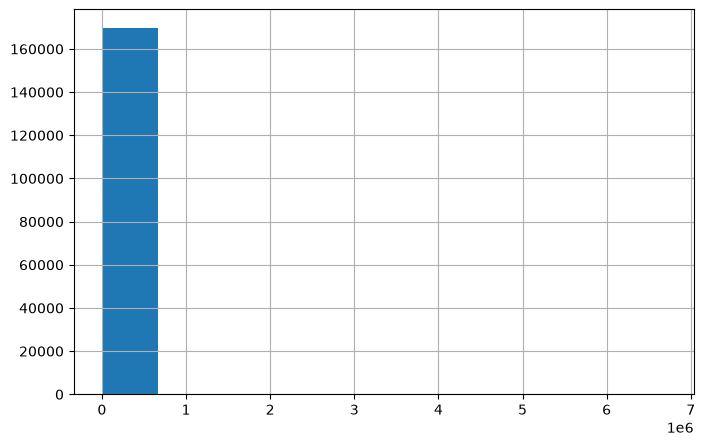

In [42]:
df['Price (in rupees)'].hist(figsize=(8,5))

In [43]:
df['Price (in rupees)'].quantile([0.95, 0.99, 0.995])

0.950    16111.00
0.990    23810.00
0.995    30969.55
Name: Price (in rupees), dtype: float64

In [44]:
df_clean = df[df['Price (in rupees)'] <= 31000]

In [45]:
df_clean.shape

(169017, 15)

In [46]:
df.head()

,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Car Parking,Ownership,Super Area
0,773,6000.0,67,1932,0,39,3,2,7,18,0,2,205,4,2897
1,1538,13799.0,67,1892,0,544,3,1,0,0,2,11,2,1,2897
2,44,17500.0,67,2307,0,57,3,2,0,0,2,11,0,1,2897
4,65,18824.0,67,2117,0,377,3,2,8,1,2,11,0,0,2897
5,803,6618.0,67,2590,0,352,3,2,0,1,0,0,205,0,2497


In [47]:
df.info()

<class 'pandas.DataFrame'>
Index: 169866 entries, 0 to 187530
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Amount(in rupees)  169866 non-null  int64  
 1   Price (in rupees)  169866 non-null  float64
 2   location           169866 non-null  int64  
 3   Carpet Area        169866 non-null  int64  
 4   Status             169866 non-null  int64  
 5   Floor              169866 non-null  int64  
 6   Transaction        169866 non-null  int64  
 7   Furnishing         169866 non-null  int64  
 8   facing             169866 non-null  int64  
 9   overlooking        169866 non-null  int64  
 10  Bathroom           169866 non-null  int64  
 11  Balcony            169866 non-null  int64  
 12  Car Parking        169866 non-null  int64  
 13  Ownership          169866 non-null  int64  
 14  Super Area         169866 non-null  int64  
dtypes: float64(1), int64(14)
memory usage: 20.7 MB


In [48]:
X = df.drop("Price (in rupees)", axis=1)
y = df["Price (in rupees)"]

print(X.shape)
print(y.shape)

(169866, 14)
(169866,)


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(135892, 14)
(33974, 14)


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(135892, 14)
(33974, 14)


In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [53]:
# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 3384.62609776958
R2 Score: 0.0023845618508968602


In [54]:
df.corr()["Price (in rupees)"].sort_values()

Amount(in rupees)   -0.039447
Carpet Area         -0.031195
Car Parking         -0.030889
overlooking         -0.024933
Ownership           -0.024020
Transaction         -0.021533
facing              -0.014271
Floor               -0.008331
Furnishing          -0.006346
Balcony             -0.004975
Status              -0.003883
Super Area           0.018122
location             0.025165
Bathroom             0.044577
Price (in rupees)    1.000000
Name: Price (in rupees), dtype: float64

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Features and target
X = df.drop("Price (in rupees)", axis=1)
y = df["Price (in rupees)"]

# Categorical columns
cat_cols = ['location','Status','Transaction','Furnishing',
            'facing','overlooking','Ownership']

# Numeric columns
num_cols = [col for col in X.columns if col not in cat_cols]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# Model
model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training
model.fit(X_train, y_train)

print("Model trained successfully!")

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Model trained successfully!
MAE: 826.290772431486
R2 Score: -0.07883943393391135


In [56]:
df.describe()

,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Car Parking,Ownership,Super Area
count,169866.000000,1.698660e+05,169866.000000,169866.000000,169866.000000,169866.000000,169866.000000,169866.000000,169866.000000,169866.000000,169866.000000,169866.000000,169866.000000,169866.000000,169866.000000
mean,674.955901,7.583772e+03,29.563309,1842.847550,0.003503,453.004362,2.284336,1.332580,3.590112,9.662563,2.395747,4.163741,116.167497,2.052012,2077.485365
std,488.024423,2.724171e+04,19.969607,939.031997,0.059081,295.208419,1.278631,0.676257,3.152865,7.557038,1.174355,4.268814,97.114431,1.432009,1091.063150
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,232.000000,4.297000e+03,13.000000,864.000000,0.000000,141.000000,3.000000,1.000000,0.000000,1.000000,2.000000,2.000000,1.000000,1.000000,910.000000
50%,643.000000,6.034000e+03,27.000000,2460.000000,0.000000,552.000000,3.000000,1.000000,2.000000,6.000000,2.000000,2.000000,205.000000,1.000000,2897.000000
75%,1119.000000,9.450000e+03,50.000000,2590.000000,0.000000,702.000000,3.000000,2.000000,7.000000,18.000000,3.000000,11.000000,205.000000,4.000000,2897.000000
max,1556.000000,6.700000e+06,80.000000,2590.000000,1.000000,931.000000,4.000000,3.000000,8.000000,18.000000,11.000000,11.000000,205.000000,4.000000,2897.000000


In [57]:
# Remove rows where price is 0
df = df[df["Price (in rupees)"] > 0]

print(df.shape)

(169855, 15)


In [58]:
df["Price (in rupees)"].describe()

count    1.698550e+05
mean     7.584263e+03
std      2.724252e+04
min      1.000000e+00
25%      4.297000e+03
50%      6.034000e+03
75%      9.451000e+03
max      6.700000e+06
Name: Price (in rupees), dtype: float64

In [59]:
upper_limit = df["Price (in rupees)"].quantile(0.99)

df = df[df["Price (in rupees)"] <= upper_limit]

print(df.shape)
print(df["Price (in rupees)"].describe())

(168159, 15)
count    168159.000000
mean       7161.554582
std        3958.994780
min           1.000000
25%        4283.000000
50%        6022.000000
75%        9161.000000
max       23810.000000
Name: Price (in rupees), dtype: float64


In [60]:
from sklearn.model_selection import train_test_split

X = df.drop("Price (in rupees)", axis=1)
y = df["Price (in rupees)"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Model trained successfully!")

y_pred = rf_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Model trained successfully!
MAE: 170.90184475960115
R2 Score: 0.9743570406792141


In [62]:
import joblib

joblib.dump(rf_model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!
